# Logistic Regression - implement from scratch

In [9]:
#libraries
import numpy as np
import matplotlib.pyplot as plt

In [10]:
#generate 4 2-Dimentional gaussian clusters
np.random.seed(0)
nSamples = 1000
variance = 0.1

means = np.array([[2, 2], [-2, 2], [2, -2], [-2, -2]])
X = []
y = []

for i, mean in enumerate(means):
    X.append(np.random.multivariate_normal(mean, variance * np.eye(2), nSamples))
    y.append(np.full(nSamples, i))

X = np.vstack(X)
y = np.concatenate(y)

In [11]:
#bias term (handling w in regression)
X = np.hstack([np.ones((X.shape[0], 1)), X]) 

# one-hot encoding labels
def oneHot(y, nClasses):
    oh = np.zeros((y.size, nClasses))
    oh[np.arange(y.size), y] = 1
    return oh

Y = oneHot(y, 4)

In [12]:
#function for softmax xalculation
def softmax(z):
    eZ = np.exp(z - np.max(z, axis=1, keepdims=True))
    return eZ / np.sum(eZ, axis=1, keepdims=True)

# cross-entropy loss function
def crossEntropy(Y, P):
    return -np.mean(np.sum(Y * np.log(P + 1e-9), axis=1))

In [13]:
#train using gradient descent
def trainLR(X, Y, lr=0.1, epochs=1000):
    nSamples, nFeatures = X.shape
    nClasses = Y.shape[1]
    W = np.zeros((nFeatures, nClasses))  #weight matrix
    
    for e in range(epochs):
        Z = X @ W
        pred = softmax(Z)
        grad = (X.T @ (pred - Y)) / nSamples
        W -= lr * grad
        
        if e % 50 == 0:
            loss = crossEntropy(Y, pred)
            print(f"Epoch {e}: Loss = {loss:.4f}")
    return W

W = trainLR(X, Y, lr=0.2, epochs=1000)

Epoch 0: Loss = 1.3863
Epoch 50: Loss = 0.0586
Epoch 100: Loss = 0.0303
Epoch 150: Loss = 0.0206
Epoch 200: Loss = 0.0156
Epoch 250: Loss = 0.0127
Epoch 300: Loss = 0.0106
Epoch 350: Loss = 0.0092
Epoch 400: Loss = 0.0081
Epoch 450: Loss = 0.0072
Epoch 500: Loss = 0.0066
Epoch 550: Loss = 0.0060
Epoch 600: Loss = 0.0055
Epoch 650: Loss = 0.0051
Epoch 700: Loss = 0.0048
Epoch 750: Loss = 0.0045
Epoch 800: Loss = 0.0042
Epoch 850: Loss = 0.0040
Epoch 900: Loss = 0.0038
Epoch 950: Loss = 0.0036


In [14]:
# predict and accuracy
def predict(X, W):
    pred = softmax(X @ W)
    return np.argmax(pred, axis=1)

yPredicted = predict(X, W)
accuracy = np.mean(yPredicted == y)
print(f"Classification Accuracy: {accuracy * 100:.3f}%")

Classification Accuracy: 100.000%


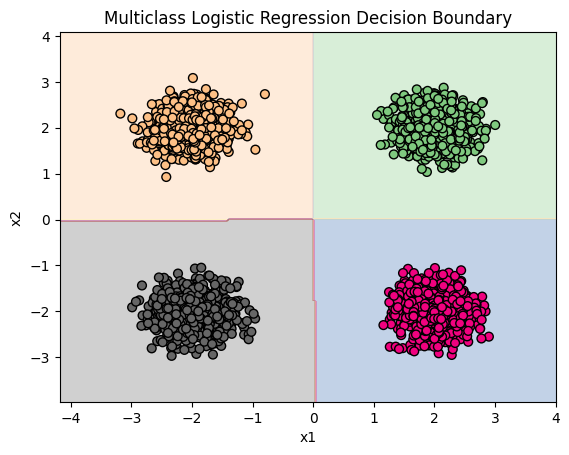

In [15]:
#decision boundary
xMin, xMax = X[:,1].min() - 1, X[:,1].max() + 1
yMin, yMax = X[:,2].min() - 1, X[:,2].max() + 1
xx, yy = np.meshgrid(np.linspace(xMin, xMax, 200),np.linspace(yMin, yMax, 200))

grid = np.c_[np.ones((xx.size, 1)), xx.ravel(), yy.ravel()]
Z = predict(grid, W)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="Accent")
plt.scatter(X[:,1], X[:,2], c=y, s=40, cmap="Accent", edgecolors="k")
plt.title("Multiclass Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()